In [137]:
import json
import networkx as nx
from pyvis.network import Network
import community as community_louvain
import matplotlib.cm as cm
from networkx.drawing.nx_agraph import graphviz_layout
from collections import Counter

# === Load graph from JSON ===
with open("austin_mutuals_graph.json") as f:
    adj_dict = json.load(f)

# === Build directed graph ===
G = nx.DiGraph()
all_nodes = set(adj_dict.keys()) | {v for neighbors in adj_dict.values() for v in neighbors}
G.add_nodes_from(all_nodes)
for u, neighbors in adj_dict.items():
    for v in neighbors:
        G.add_edge(u, v)

# === Identify mutual follows
mutual_pairs = {tuple(sorted((u, v))) for u, v in G.edges() if G.has_edge(v, u)}

# === Community detection
G_undirected = G.to_undirected()
partition = community_louvain.best_partition(G_undirected)
num_communities = len(set(partition.values()))
nx.set_node_attributes(G, partition, "community")

# === Compute node-level stats
clustering = nx.clustering(G_undirected)
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

# === Color mapping per community
color_map = cm.get_cmap("tab20", num_communities)
def community_to_hex(comm_id):
    rgba = color_map(comm_id % color_map.N)
    return '#%02x%02x%02x' % (int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255))

# === Get fixed node positions from Graphviz
positions = graphviz_layout(G, prog="sfdp")

# === Initialize PyVis network with physics turned off
nt = Network(height="900px", width="100%", directed=True, notebook=False)
nt.set_options("""
{
  "physics": { "enabled": false },
  "interaction": {
    "hover": true,
    "navigationButtons": true,
    "keyboard": true,
    "multiselect": true,
    "tooltipDelay": 100
  },
  "nodes": {
    "shape": "dot",
    "size": 20,
    "font": { "size": 14, "face": "arial" },
    "borderWidth": 2,
    "borderWidthSelected": 6,
    "color": {
      "border": "#2B7CE9",
      "background": "#97C2FC",
      "highlight": { "border": "#FF0000", "background": "#FFEE88" },
      "hover": { "border": "#FFA500", "background": "#FFFFCC" }
    },
    "chosen": true
  },
  "edges": {
    "color": {
      "color": "#000000",
      "highlight": "#FF0000",
      "hover": "#FF9900",
      "inherit": false
    },
    "width": 1,
    "hoverWidth": 4,
    "selectionWidth": 40,
    "smooth": { "enabled": false }
  }
}
""")

# === Add nodes with fixed positions and hover tooltips
SCALE = 15
for node in G.nodes():
    comm_id = partition[node]
    color = community_to_hex(comm_id)
    x = positions[node][0]*SCALE
    y = positions[node][1]*SCALE
    tooltip = (
        f"{node}, "
        f"Community: {comm_id}, "
        f"In-Degree: {in_deg.get(node, 0)}, "
        f"Out-Degree: {out_deg.get(node, 0)}, "
        f"Clustering: {clustering.get(node):.3f}"
    )
    nt.add_node(
        node,
        label=node,
        title=tooltip,
        color=color,
        x=x,
        y=y,
        fixed=True,
        group=str(comm_id),
        data={"group": str(comm_id)}
    )

# === Add edges
for u, v in G.edges():
    pair = tuple(sorted((u, v)))
    if pair in mutual_pairs:
        nt.add_edge(u, v, color='gray', width=1, arrows="")
    else:
        nt.add_edge(u, v, color='green', width=1, arrows='to')

# === Count community sizes
comm_sizes = Counter(partition.values())

# === Write to HTML with community filters
def write_pyvis_with_filters(net, path, comm_sizes):
    net.write_html(path, open_browser=False)

    with open(path, 'r') as f:
        html = f.read()

    # === Sidebar HTML for community checkboxes
    checkbox_html = """
<div style="display: flex; height: 100vh;">
  <div style="width: 250px; padding: 10px; overflow-y: auto; border-right: 1px solid #ccc;">
    <b>Filter by Community:</b><br>
    <button id="toggleAll" style="margin: 5px 0;">Select None</button><br>
"""
    for comm, size in sorted(comm_sizes.items()):
        checkbox_html += f"""
    <label>
      <input type="checkbox" class="communityCheckbox" value="{comm}" checked>
      Community {comm} ({size} Nodes)
    </label><br>
"""
    checkbox_html += "</div>\n<div id='graph-container' style='flex-grow: 1;'>"

    # === Wrap the network canvas with a container div
    html = html.replace('<body>', f'<body>{checkbox_html}')
    html = html.replace('</body>', '</div></div></body>')

    # === JavaScript for checkbox filtering
    script = """
<script type="text/javascript">
document.addEventListener("DOMContentLoaded", function () {
    setTimeout(function () {
        const allNodes = network.body.data.nodes.get();
        const allEdges = network.body.data.edges.get();

        const originalNodes = [...allNodes];
        const originalEdges = [...allEdges];

        function updateCommunityFilter() {
            const checked = Array.from(document.querySelectorAll('.communityCheckbox:checked')).map(cb => cb.value);
            const filteredNodes = originalNodes.filter(n => checked.includes(n.group.toString()));
            const nodeIds = filteredNodes.map(n => n.id);
            const filteredEdges = originalEdges.filter(e => nodeIds.includes(e.from) && nodeIds.includes(e.to));
            network.setData({
                nodes: new vis.DataSet(filteredNodes),
                edges: new vis.DataSet(filteredEdges)
            });
        }

        document.querySelectorAll('.communityCheckbox').forEach(cb => {
            cb.addEventListener('change', updateCommunityFilter);
        });

        document.getElementById("toggleAll").addEventListener("click", function () {
            const checkboxes = document.querySelectorAll('.communityCheckbox');
            const allChecked = Array.from(checkboxes).every(cb => cb.checked);
            checkboxes.forEach(cb => cb.checked = !allChecked);
            this.innerText = allChecked ? "Select All" : "Select None";
            updateCommunityFilter();
        });
    }, 500);
});
</script>
"""
    html = html.replace('</body>', script + '</body>')

    with open(path, 'w') as f:
        f.write(html)

# === Write final HTML
write_pyvis_with_filters(nt, "mutuals_graph_pyvis.html", comm_sizes)


/var/folders/8k/klzglr3x2jl86hl862ddgsm00000gn/T/ipykernel_61272/1771487750.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap("tab20", num_communities)


In [138]:
import networkx as nx
import numpy as np
import pandas as pd

# Basic Graph Analysis

# Number of nodes and edges
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# In-degree and out-degree
in_degrees = [deg for _, deg in G.in_degree()]
out_degrees = [deg for _, deg in G.out_degree()]

avg_in_degree = np.mean(in_degrees)
avg_out_degree = np.mean(out_degrees)
max_in_degree = np.max(in_degrees)
max_out_degree = np.max(out_degrees)
min_in_degree = np.min(in_degrees)
min_out_degree = np.min(out_degrees)

# Weakly connected components
num_connected_components = nx.number_weakly_connected_components(G)
largest_cc = max(nx.weakly_connected_components(G), key=len)
subgraph_largest_cc = G.subgraph(largest_cc)

# Display results
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Average in-degree: {avg_in_degree:.2f}")
print(f"Average out-degree: {avg_out_degree:.2f}")
print(f"Max in-degree: {max_in_degree}, Min in-degree: {min_in_degree}")
print(f"Max out-degree: {max_out_degree}, Min out-degree: {min_out_degree}")
print(f"Number of weakly connected components: {num_connected_components}")
print(f"Size of largest connected component: {len(largest_cc)}")


Number of nodes: 328
Number of edges: 7298
Average in-degree: 22.25
Average out-degree: 22.25
Max in-degree: 85, Min in-degree: 0
Max out-degree: 84, Min out-degree: 0
Number of weakly connected components: 7
Size of largest connected component: 320


In [139]:
import networkx as nx
from torch_geometric.utils import to_networkx


# Compute in-degrees and out-degrees
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = {node: in_degrees[node] + out_degrees[node] for node in G.nodes()}
# Sort by total degree
top_total = sorted(total_degrees.items(), key=lambda x: x[1], reverse=True)


print("Top 10 nodes by total-degree:")
for node, deg in top_total[:10]:
    print(f"Node {node}: {in_degrees[node]} incoming edges and {out_degrees[node]} outgoing edges")

print("\nBottom 10 nodes by total-degree:")
for node, deg in top_total[-1:-11:-1]:
    print(f"Node {node}: {in_degrees[node]} incoming edges and {out_degrees[node]} outgoing edges")






Top 10 nodes by total-degree:
Node mateoandthecity: 70 incoming edges and 84 outgoing edges
Node joe_n98: 70 incoming edges and 72 outgoing edges
Node huijia_yu: 70 incoming edges and 71 outgoing edges
Node parker.lyy: 68 incoming edges and 69 outgoing edges
Node bnhenny: 65 incoming edges and 67 outgoing edges
Node setpheap_s: 65 incoming edges and 65 outgoing edges
Node gothamvolleyball: 85 incoming edges and 43 outgoing edges
Node raydolphzhong: 64 incoming edges and 64 outgoing edges
Node johnnyoconnell: 64 incoming edges and 64 outgoing edges
Node mattjlew: 63 incoming edges and 63 outgoing edges

Bottom 10 nodes by total-degree:
Node wk3r_b0t: 0 incoming edges and 0 outgoing edges
Node kabz20: 0 incoming edges and 0 outgoing edges
Node jsonh: 0 incoming edges and 0 outgoing edges
Node trocbayb: 0 incoming edges and 0 outgoing edges
Node ya.shimmy: 1 incoming edges and 1 outgoing edges
Node chrispynyc: 1 incoming edges and 1 outgoing edges
Node imnotjanson: 1 incoming edges and 1 

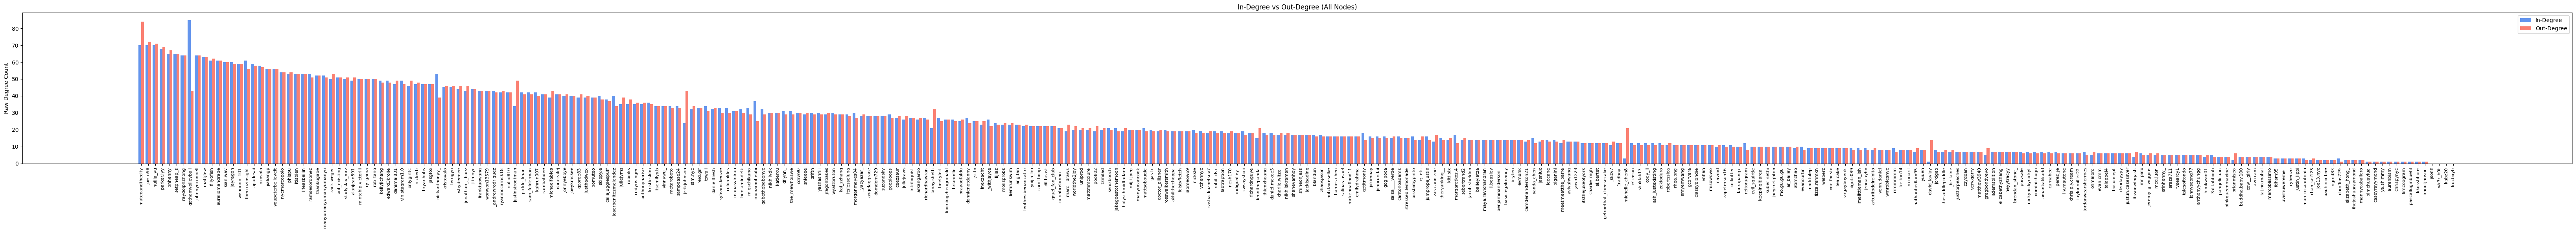

In [140]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Compute raw degree counts
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = {node: in_degrees.get(node, 0) + out_degrees.get(node, 0) for node in G.nodes()}

# Create DataFrame
degree_df = pd.DataFrame({
    "in_degree": pd.Series(in_degrees),
    "out_degree": pd.Series(out_degrees),
    "total_degree": pd.Series(total_degrees)
})

# Sort by total degree
degree_df = degree_df.sort_values("total_degree", ascending=False)

# Plot
x = np.arange(len(degree_df))
width = 0.4

plt.figure(figsize=(max(12, len(degree_df) * 0.2), 6))
plt.bar(x - width/2, degree_df["in_degree"], width, label="In-Degree", color="cornflowerblue")
plt.bar(x + width/2, degree_df["out_degree"], width, label="Out-Degree", color="salmon")

plt.xticks(x, degree_df.index, rotation=90, fontsize=8)
plt.ylabel("Raw Degree Count")
plt.title("In-Degree vs Out-Degree (All Nodes)")
plt.legend()
plt.tight_layout()
plt.show()


In [141]:
import pandas as pd
import networkx as nx
import community as community_louvain

# === Compute metrics ===
UG = G.to_undirected()
metrics = {
    "degree_centrality": nx.degree_centrality(G),
    "in_degree_centrality": nx.in_degree_centrality(G),
    "out_degree_centrality": nx.out_degree_centrality(G),
    "closeness_centrality": nx.closeness_centrality(G),
    "betweenness_centrality": nx.betweenness_centrality(G),
    "pagerank": nx.pagerank(G),
    "load_centrality": nx.load_centrality(G),
    "hits_hub": nx.hits(G)[0],
    "hits_auth": nx.hits(G)[1],
    "clustering": nx.clustering(UG),
    "triangles": nx.triangles(UG)
}

# Optional metrics
try:
    metrics["eigenvector_centrality"] = nx.eigenvector_centrality(G, max_iter=1000)
except:
    metrics["eigenvector_centrality"] = None

try:
    metrics["square_clustering"] = nx.square_clustering(UG)
except:
    metrics["square_clustering"] = None

# === Build DataFrame ===
df = pd.DataFrame({k: v for k, v in metrics.items() if isinstance(v, dict)})

# === Add community ID ===
partition = community_louvain.best_partition(UG)
df["community"] = pd.Series(partition)

# === Export CSV ===
df.to_csv("node_metrics_with_community.csv", index_label="username")

# === Build ASCII bar chart leaderboard ===
def ascii_bar(score, min_val, max_val, width=10):
    if max_val == min_val:
        return '-' * width
    norm = (score - min_val) / (max_val - min_val)
    bars = int(norm * width)
    return '#' * bars + '-' * (width - bars)

ascii_leaderboard = pd.DataFrame()

for col in df.columns:
    if col == "community":
        continue
    sorted_col = df[col].sort_values(ascending=False)
    min_val, max_val = sorted_col.min(), sorted_col.max()

    ascii_formatted = [
        f"{idx}: {val:.4f} [{ascii_bar(val, min_val, max_val)}]"
        for idx, val in sorted_col.items()
    ]

    ascii_leaderboard[col] = ascii_formatted

# === Print result ===
print("\nFull ASCII Leaderboard (Sorted Columns):")
print(ascii_leaderboard.to_string(index=False))



Full ASCII Leaderboard (Sorted Columns):
                        degree_centrality                      in_degree_centrality                     out_degree_centrality                      closeness_centrality                    betweenness_centrality                                  pagerank                           load_centrality                                  hits_hub                                 hits_auth                                clustering                                   triangles                    eigenvector_centrality                         square_clustering
     mateoandthecity: 0.4709 [##########]     gothamvolleyball: 0.2599 [##########]      mateoandthecity: 0.2569 [##########]              joe_n98: 0.4446 [##########]              joe_n98: 0.0967 [##########]            huijia_yu: 0.0100 [##########]              joe_n98: 0.0984 [##########]      mateoandthecity: 0.0187 [##########]     gothamvolleyball: 0.0188 [##########]              ryhenzo: 1.0000 [##

In [142]:
import networkx as nx
import numpy as np
import pandas as pd

# === Helpers ===
def largest_weakly_connected_subgraph(G):
    wccs = list(nx.weakly_connected_components(G))
    largest_wcc = max(wccs, key=len)
    return G.subgraph(largest_wcc).copy()

def largest_strongly_connected_subgraph(G):
    sccs = list(nx.strongly_connected_components(G))
    largest_scc = max(sccs, key=len)
    return G.subgraph(largest_scc).copy()

# === Compute graph-level statistics ===
def compute_graph_stats(G):
    stats = {}
    stats["is_directed"] = G.is_directed()
    stats["number_of_nodes"] = G.number_of_nodes()
    stats["number_of_edges"] = G.number_of_edges()
    stats["density"] = nx.density(G)

    in_degrees = dict(G.in_degree()) if G.is_directed() else {}
    out_degrees = dict(G.out_degree()) if G.is_directed() else {}
    degrees = dict(G.degree())

    stats["avg_in_degree"] = np.mean(list(in_degrees.values())) if in_degrees else None
    stats["avg_out_degree"] = np.mean(list(out_degrees.values())) if out_degrees else None
    stats["avg_total_degree"] = np.mean(list(degrees.values()))
    stats["max_in_degree"] = max(in_degrees.values()) if in_degrees else None
    stats["max_out_degree"] = max(out_degrees.values()) if out_degrees else None

    try:
        stats["average_clustering"] = nx.average_clustering(G.to_undirected())
        stats["transitivity"] = nx.transitivity(G)
        stats["average_neighbor_degree"] = np.mean(list(nx.average_neighbor_degree(G).values()))
    except:
        stats["average_clustering"] = None
        stats["transitivity"] = None
        stats["average_neighbor_degree"] = None

    try:
        stats["reciprocity"] = nx.reciprocity(G) if G.is_directed() else None
    except:
        stats["reciprocity"] = None

    try:
        stats["degree_assortativity"] = nx.degree_assortativity_coefficient(G)
    except:
        stats["degree_assortativity"] = None

    try:
        stats["global_efficiency"] = nx.global_efficiency(G.to_undirected())
    except:
        stats["global_efficiency"] = None

    try:
        stats["num_triangles"] = sum(nx.triangles(G.to_undirected()).values()) // 3
    except:
        stats["num_triangles"] = None

    try:
        if G.is_directed():
            W = G if nx.is_weakly_connected(G) else largest_weakly_connected_subgraph(G)
            S = G if nx.is_strongly_connected(G) else largest_strongly_connected_subgraph(G)
        else:
            W = G if nx.is_connected(G) else G.subgraph(max(nx.connected_components(G), key=len))
            S = W

        stats["diameter"] = nx.diameter(S.to_undirected())
        stats["avg_shortest_path_length"] = nx.average_shortest_path_length(S)
        stats["radius"] = nx.radius(S.to_undirected())
        ecc = nx.eccentricity(S.to_undirected())
        stats["avg_eccentricity"] = np.mean(list(ecc.values()))
    except:
        stats["diameter"] = None
        stats["avg_shortest_path_length"] = None
        stats["radius"] = None
        stats["avg_eccentricity"] = None

    try:
        degree_values = np.array(list(degrees.values()))
        degree_sum = degree_values.sum()
        if degree_sum == 0 or len(degree_values) == 0:
            stats["degree_entropy"] = 0.0
        else:
            p = degree_values / degree_sum
            p = p[p > 0]  # Remove zero probabilities to avoid log2(0)
            stats["degree_entropy"] = -np.sum(p * np.log2(p))
    except:
        stats["degree_entropy"] = None



    try:
        if G.is_directed():
            stats["num_weakly_connected_components"] = nx.number_weakly_connected_components(G)
            stats["num_strongly_connected_components"] = nx.number_strongly_connected_components(G)
        else:
            stats["num_connected_components"] = nx.number_connected_components(G)
    except:
        stats["num_weakly_connected_components"] = None
        stats["num_strongly_connected_components"] = None
        stats["num_connected_components"] = None

    return stats

# === Global and per-community stats ===
global_stats = compute_graph_stats(G)
global_stats["community"] = "ALL"

community_ids = set(nx.get_node_attributes(G, "community").values())
all_stats = [global_stats]

for comm_id in sorted(community_ids):
    nodes = [n for n, d in G.nodes(data=True) if d.get("community") == comm_id]
    G_comm = G.subgraph(nodes).copy()
    stats = compute_graph_stats(G_comm)
    stats["community"] = comm_id
    all_stats.append(stats)

# === Final dataframe ===
df = pd.DataFrame(all_stats)
df = df.set_index("community").T  # Transpose so rows = metrics, columns = communities
df = df.round(4)
print(df)


community                                ALL          0          1          2  \
is_directed                             True       True       True       True   
number_of_nodes                          328         42         94         95   
number_of_edges                         7298        509       3498       1971   
density                             0.068043   0.295587   0.400137   0.220717   
avg_in_degree                          22.25  12.119048  37.212766  20.747368   
avg_out_degree                         22.25  12.119048  37.212766  20.747368   
avg_total_degree                        44.5  24.238095  74.425532  41.494737   
max_in_degree                             85         30         75         65   
max_out_degree                            84         29         75         66   
average_clustering                  0.549925   0.719997   0.649578   0.678331   
transitivity                        0.516004   0.615085   0.594299   0.511087   
average_neighbor_degree     

/Users/samantha/instagram_network_analysis/.venv/lib/python3.11/site-packages/networkx/algorithms/assortativity/mixing.py:217: RuntimeWarning: invalid value encountered in divide
  a = a / a.sum()
/Users/samantha/instagram_network_analysis/.venv/lib/python3.11/site-packages/networkx/algorithms/assortativity/correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


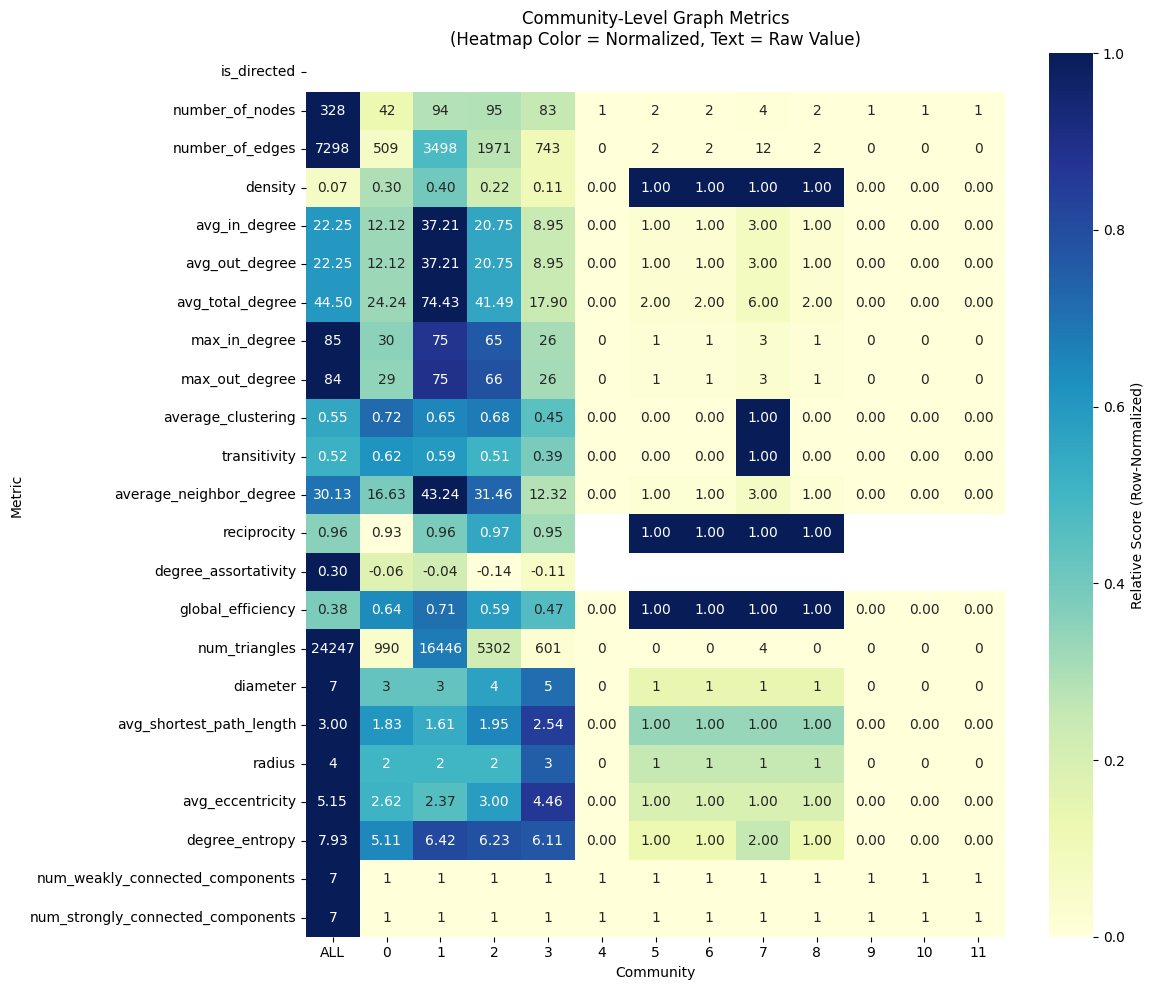

In [143]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure numeric and drop non-numeric rows
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# === Normalize by metric (row) for coloring ===
df_colors = df_numeric.subtract(df_numeric.min(axis=1), axis=0)
df_colors = df_colors.divide(df_numeric.max(axis=1) - df_numeric.min(axis=1), axis=0)

# === Format annotations: no decimals for integer-like metrics ===
annot_df = df_numeric.copy().astype(object)

for metric in annot_df.index:
    all_values = annot_df.loc[metric].dropna()
    # If all values are whole numbers, treat as integer-like
    is_integer = all((float(x).is_integer() for x in all_values))
    
    if is_integer:
        annot_df.loc[metric] = annot_df.loc[metric].apply(lambda x: f"{int(x)}" if pd.notna(x) else "")
    else:
        annot_df.loc[metric] = annot_df.loc[metric].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "")

# === Plot heatmap ===
plt.figure(figsize=(12, 10))
sns.heatmap(
    df_colors,
    annot=annot_df,
    fmt="",
    cmap="YlGnBu",
    cbar_kws={'label': 'Relative Score (Row-Normalized)'}
)
plt.title("Community-Level Graph Metrics\n(Heatmap Color = Normalized, Text = Raw Value)")
plt.xlabel("Community")
plt.ylabel("Metric")
plt.tight_layout()
plt.show()


In [144]:
import torch
from torch_geometric.utils import from_networkx
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit

# === Count new community sizes
comm_sizes = Counter(partition.values())

# === Filter again: remove any community with < 2 nodes
valid_comms = {c for c, sz in comm_sizes.items() if sz >= 2}
G = G.subgraph([n for n in G.nodes if partition[n] in valid_comms]).copy()

# === Final Louvain on fully filtered graph
partition = community_louvain.best_partition(G.to_undirected())

# === Structural features
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())
total_deg = {n: in_deg[n] + out_deg[n] for n in G.nodes()}
clustering = nx.clustering(G.to_undirected())
pagerank = nx.pagerank(G)

# === Normalize Louvain community as numeric feature
comm_map = {c: i for i, c in enumerate(sorted(set(partition.values())))}
community_ids = {n: comm_map[partition[n]] for n in G.nodes()}
max_comm = max(community_ids.values())
norm_community = {n: community_ids[n] / max_comm for n in G.nodes()}

# === Build feature matrix
features = []
for n in G.nodes():
    features.append([
        in_deg[n],
        out_deg[n],
        total_deg[n],
        clustering[n],
        pagerank[n],
        norm_community[n]
    ])

# === Normalize features
scaler = StandardScaler()
x_tensor = torch.tensor(scaler.fit_transform(features), dtype=torch.float)

# === Convert to PyG Data object
features = np.array([
    [in_deg[n], out_deg[n], in_deg[n] + out_deg[n], clustering[n]]
    for n in G.nodes()
])
scaler = StandardScaler()
x_tensor = torch.tensor(scaler.fit_transform(features), dtype=torch.float)
label_tensor = torch.tensor([partition[n] for n in G.nodes()], dtype=torch.long)
data = from_networkx(G)
data.x = x_tensor
data.y = label_tensor

# === Stratified Train/Test split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
labels = data.y.numpy()
train_idx, test_idx = next(sss.split(np.zeros(len(labels)), labels))
data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.train_mask[train_idx] = True
data.test_mask[test_idx] = True

# === Define GCN
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# === Train GCN
model = GCN(data.x.shape[1], hidden_channels=16, out_channels=int(data.y.max()) + 1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        model.eval()
        pred = out.argmax(dim=1)
        acc = (pred[data.test_mask] == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Test Acc: {acc:.4f}")

Epoch 000 | Loss: 2.0771 | Test Acc: 0.0462
Epoch 010 | Loss: 1.5086 | Test Acc: 0.6154
Epoch 020 | Loss: 1.1576 | Test Acc: 0.6154
Epoch 030 | Loss: 0.9627 | Test Acc: 0.7231
Epoch 040 | Loss: 0.8221 | Test Acc: 0.8154
Epoch 050 | Loss: 0.6865 | Test Acc: 0.8769
Epoch 060 | Loss: 0.5647 | Test Acc: 0.9385
Epoch 070 | Loss: 0.4756 | Test Acc: 0.9231
Epoch 080 | Loss: 0.4182 | Test Acc: 0.9231
Epoch 090 | Loss: 0.3786 | Test Acc: 0.9231


/Users/samantha/instagram_network_analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/samantha/instagram_network_analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/samantha/instagram_network_analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/samantha/instagram_network_analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/samantha/instagram_network_analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/samantha/instagram_network_analysis/.venv/lib/python3.11/site-

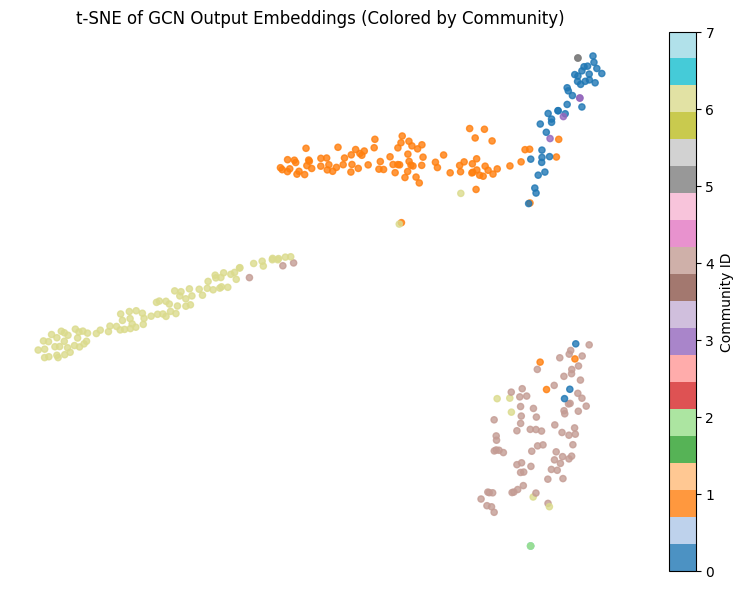

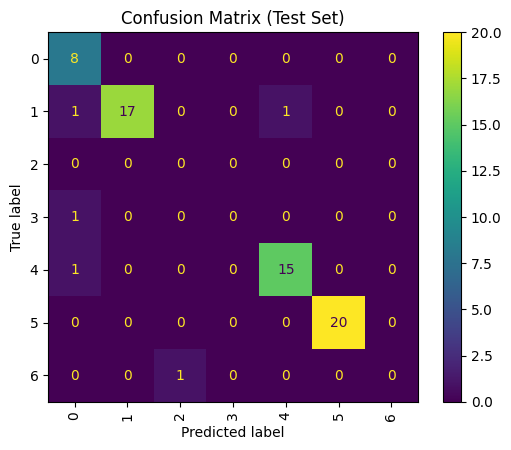

Per-Community Accuracy:
  Community 0: 100.00%
  Community 1: 89.47%
  Community 3: 0.00%
  Community 4: 93.75%
  Community 6: 100.00%
  Community 7: 0.00%


In [145]:
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# === Evaluate model and get logits ===
model.eval()
logits = model(data.x, data.edge_index).detach()
pred = logits.argmax(dim=1).cpu()
true = data.y.cpu()
test_mask = data.test_mask.cpu()

# === t-SNE Visualization ===
z_tsne = TSNE(n_components=2, random_state=42).fit_transform(logits.cpu())

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    z_tsne[:, 0], z_tsne[:, 1],
    c=true, cmap='tab20', s=20, alpha=0.8
)
plt.title("t-SNE of GCN Output Embeddings (Colored by Community)")
plt.axis('off')
plt.colorbar(scatter, label='Community ID')


plt.show()

# === Confusion Matrix (on test set) ===
cm = confusion_matrix(true[test_mask], pred[test_mask])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix (Test Set)")
plt.show()

# === Per-Class Accuracy ===
labels = true[test_mask].numpy()
correct = (pred[test_mask] == true[test_mask]).numpy()

print("Per-Community Accuracy:")
for cls in np.unique(labels):
    cls_mask = labels == cls
    acc = correct[cls_mask].sum() / cls_mask.sum()
    print(f"  Community {cls}: {acc:.2%}")


In [146]:
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

# === Check community overlap ===
train_labels = data.y[data.train_mask].numpy()
test_labels = data.y[data.test_mask].numpy()
train_comms = set(np.unique(train_labels))
test_comms = set(np.unique(test_labels))
missing_in_train = test_comms - train_comms

print("✅ Diagnostic: Community Coverage")
print("Train communities:", sorted(train_comms))
print("Test communities :", sorted(test_comms))
if missing_in_train:
    print("❗ Warning: Test set contains unseen communities:", sorted(missing_in_train))
else:
    print("✅ All test communities are present in training set.\n")

# === Check label distribution ===
num_classes = len(np.unique(data.y.numpy()))
print(f"✅ Total number of classes: {num_classes}")

# === Check prediction collapse (only if model has been trained) ===
try:
    model.eval()
    with torch.no_grad():
        preds = model(data.x, data.edge_index).argmax(dim=1).cpu().numpy()
    unique, counts = np.unique(preds[data.test_mask], return_counts=True)
    print("\n✅ Prediction Distribution (test set):")
    for u, c in zip(unique, counts):
        print(f"  Class {u}: {c} nodes")
    if len(unique) == 1:
        print("❗ Model is predicting only one class.")
    else:
        print("✅ Model is predicting multiple classes.\n")
except Exception as e:
    print("⚠️  Could not compute predictions:", e)

# === Normalize features ===
print("\n✅ Normalizing features with StandardScaler...")
scaler = StandardScaler()
data.x = torch.tensor(scaler.fit_transform(data.x.cpu().numpy()), dtype=torch.float)
print("✅ Feature normalization complete. Re-run training for effect.\n")


✅ Diagnostic: Community Coverage
Train communities: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Test communities : [np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7)]
✅ All test communities are present in training set.

✅ Total number of classes: 8

✅ Prediction Distribution (test set):
  Class 0: 11 nodes
  Class 1: 17 nodes
  Class 2: 1 nodes
  Class 4: 16 nodes
  Class 6: 20 nodes
✅ Model is predicting multiple classes.


✅ Normalizing features with StandardScaler...
✅ Feature normalization complete. Re-run training for effect.



In [147]:
import torch
import torch.nn.functional as F
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv
from sklearn.metrics import roc_auc_score, average_precision_score

# === Step 1: Split edges into train/val/test sets ===
transform = RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    is_undirected=True,
    add_negative_train_samples=True,
    split_labels=True
)
train_data, val_data, test_data = transform(data)

# === Step 2: Define GCN Encoder ===
class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

# === Step 3: Define edge decoder (dot product)
def decode(z, edge_index):
    return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=1)

# === Step 4: Define loss
def compute_loss(z, pos_edge_index, neg_edge_index):
    pos_score = decode(z, pos_edge_index)
    neg_score = decode(z, neg_edge_index)
    pos_loss = -F.logsigmoid(pos_score).mean()
    neg_loss = -F.logsigmoid(-neg_score).mean()
    return pos_loss + neg_loss

# === Step 5: Train the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCNEncoder(data.x.size(-1), hidden_channels=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
x = train_data.x.to(device)

for epoch in range(1, 201):
    model.train()
    optimizer.zero_grad()
    z = model(x, train_data.edge_index.to(device))
    loss = compute_loss(z, train_data.pos_edge_label_index.to(device), train_data.neg_edge_label_index.to(device))
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d}, Loss: {loss.item():.4f}")

# === Step 6: Evaluate on test set
model.eval()
with torch.no_grad():
    z = model(x, train_data.edge_index.to(device))
    edge_index = test_data.pos_edge_label_index.to(device)
    neg_edge_index = test_data.neg_edge_label_index.to(device)

    pos_pred = torch.sigmoid(decode(z, edge_index)).cpu()
    neg_pred = torch.sigmoid(decode(z, neg_edge_index)).cpu()
    y_true = torch.cat([torch.ones(pos_pred.size(0)), torch.zeros(neg_pred.size(0))])
    y_scores = torch.cat([pos_pred, neg_pred])
    
    auc = roc_auc_score(y_true, y_scores)
    ap = average_precision_score(y_true, y_scores)

print(f"\n🔍 Link Prediction Results:")
print(f"AUC: {auc:.4f}")
print(f"Average Precision: {ap:.4f}")


Epoch 020, Loss: 1.0169
Epoch 040, Loss: 0.9425
Epoch 060, Loss: 0.9238
Epoch 080, Loss: 0.9047
Epoch 100, Loss: 0.8959
Epoch 120, Loss: 0.8944
Epoch 140, Loss: 0.8905
Epoch 160, Loss: 0.8888
Epoch 180, Loss: 0.8871
Epoch 200, Loss: 0.8881

🔍 Link Prediction Results:
AUC: 0.9157
Average Precision: 0.9115



🔝 Top 10 Predicted Links:


,user1,user2,score,label
343,lifeasbeilin,ramsesordonez,0.997589,1
322,whydeeeee,mintchip.victorlii,0.997491,1
145,kristovalo,ramsesordonez,0.996881,1
118,celiajugglespuff,ramsesordonez,0.996685,1
251,huijia_yu,pickle_khan,0.996020,1
329,lifeasbeilin,celiajugglespuff,0.995828,1
318,pickle_khan,mintchip.victorlii,0.995024,1
35,sumbahdee,ramsesordonez,0.993633,1
48,vinnywu_,ramsesordonez,0.993565,1
128,bnhenny,joe_n98,0.993505,1



❌ Top False Positives (Predicted link, doesn't exist):


,user1,user2,score,label
246,thecruzinsight,vin.stagram1.0,0.980670,0
277,gruel_fan_club,mintchip.victorlii,0.978669,0
24,bryanhobs,anthonyharise,0.970600,0
252,johnrundai,talesoftondo,0.968782,0
86,_yazyazar_,gothamvolleyball,0.962089,0



⚠️ Top False Negatives (True link, model missed it):


,user1,user2,score,label
304,ijusthadwex,nicksle,0.253619,1
273,charlie_mgh,arturitodelreinito,0.267057,1
337,__zainabrehman__,tanay.sheth,0.308334,1
92,_mr_palo,danimal831,0.316294,1
192,charlie_mgh,johnnyoconnell,0.320816,1


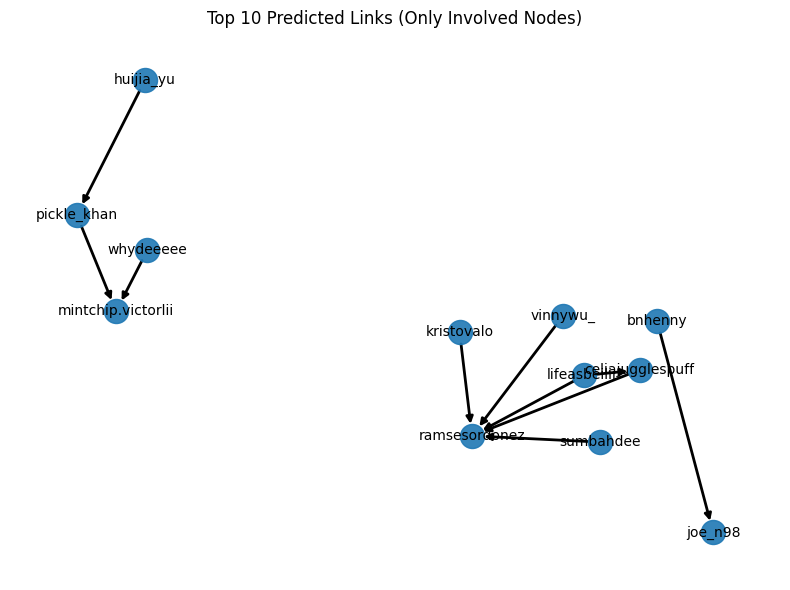

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import torch

# === Map indices back to usernames ===
node_list = list(G.nodes())
idx_to_user = {i: user for i, user in enumerate(node_list)}

# === Run model on test edges
model.eval()
with torch.no_grad():
    z = model(x, train_data.edge_index.to(device))
    pos_scores = torch.sigmoid(decode(z, test_data.pos_edge_label_index.to(device))).cpu()
    neg_scores = torch.sigmoid(decode(z, test_data.neg_edge_label_index.to(device))).cpu()

# === Convert edges from indices to usernames
def idx_pair_to_user(pair):
    return (idx_to_user[int(pair[0])], idx_to_user[int(pair[1])])

pos_edges = [idx_pair_to_user(p) for p in test_data.pos_edge_label_index.t()]
neg_edges = [idx_pair_to_user(p) for p in test_data.neg_edge_label_index.t()]

pos_df = pd.DataFrame(pos_edges, columns=["user1", "user2"])
pos_df["score"] = pos_scores.numpy()
pos_df["label"] = 1

neg_df = pd.DataFrame(neg_edges, columns=["user1", "user2"])
neg_df["score"] = neg_scores.numpy()
neg_df["label"] = 0

all_df = pd.concat([pos_df, neg_df]).sort_values("score", ascending=False)

# === Top predictions, false positives, false negatives
threshold = 0.5
top_preds = all_df.head(10)
false_positives = neg_df[neg_df["score"] > threshold].sort_values("score", ascending=False).head(5)
false_negatives = pos_df[pos_df["score"] < threshold].sort_values("score", ascending=True).head(5)

# === Show results
print("\n🔝 Top 10 Predicted Links:")
display(top_preds)

print("\n❌ Top False Positives (Predicted link, doesn't exist):")
display(false_positives)

print("\n⚠️ Top False Negatives (True link, model missed it):")
display(false_negatives)


# === Visualize top predicted links as subgraph
top_graph = nx.DiGraph()
nodes_in_top = set(top_preds["user1"]) | set(top_preds["user2"])
top_graph.add_nodes_from(nodes_in_top)

for _, row in top_preds.iterrows():
    top_graph.add_edge(row["user1"], row["user2"], weight=row["score"])

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(top_graph, seed=42)
edges, weights = zip(*nx.get_edge_attributes(top_graph, "weight").items())
nx.draw_networkx_nodes(top_graph, pos, node_size=300, alpha=0.9)
nx.draw_networkx_edges(top_graph, pos, edgelist=edges, width=2)
nx.draw_networkx_labels(top_graph, pos, font_size=10)
plt.title("Top 10 Predicted Links (Only Involved Nodes)")
plt.axis("off")
plt.tight_layout()
plt.show()
